In [ ]:
from dotenv import load_dotenv
from pathlib import Path

c:\Users\paris\Documents\Cours Centrale 3A\technical-test\injury-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Database handling
## Nutrition data

To test the food calorie estimation model :

In [ ]:
from utils.calorie_estimation import CalorieEstimation

# Initialize CalorieEstimation using the utility class
model = CalorieEstimation()

# Predict calories for a food image
photo_path = r"data\p01\food-images\IMG_8916.jpeg"
calories = model.predict(photo_path)
print(f"Estimated: {calories:.0f} calories")

[INFO] Downloading/Verifying CalorieCLIP model files locally...


Fetching 19 files: 100%|██████████| 19/19 [00:00<00:00, 142.33it/s]
c:\Users\paris\Documents\Cours Centrale 3A\technical-test\injury-prediction\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[INFO] Loading CalorieCLIP into memory on device: cpu...
[INFO] Model loaded successfully!
Estimated: 218 calories


Estimating calories for each player's photos, extracting photo dates, creating individual DataFrames, and concatenating them into a single DataFrame:

In [4]:
from pathlib import Path
from PIL import Image
import pandas as pd
from utils.calorie_estimation import CalorieEstimation

# Initialize CalorieEstimation using the utility class
model = CalorieEstimation()

players = ["p01", "p03", "p05"]
player_dfs = []
BATCH_SIZE = 32

for player in players:
    player_path = Path(f"data/{player}/food-images")
    if not player_path.exists():
        continue
    
    image_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG"):
        image_paths.extend(list(player_path.glob(ext)))
    
    if not image_paths:
        continue
        
    dates = []
    calories_list = []
    
    for i in range(0, len(image_paths), BATCH_SIZE):
        batch_paths = image_paths[i:i + BATCH_SIZE]
        calories_batch = model.predict_batch(batch_paths)
        
        for img_path, cals in zip(batch_paths, calories_batch):
            img = Image.open(img_path)
            exif = img.getexif()
            dt = None
            if exif:
                dt_str = exif.get(306)
                if 34665 in exif:
                    sub_exif = exif.get_ifd(34665)
                    dt_str = sub_exif.get(36867, dt_str)
                if dt_str:
                    try:
                        dt = dt_str.split(' ')[0].replace(':', '-')
                    except Exception:
                        dt = dt_str
            if not dt:
                dt = pd.to_datetime(img_path.stat().st_mtime, unit='s').strftime('%Y-%m-%d')
                
            dates.append(dt)
            calories_list.append(float(cals))
            
    df_player = pd.DataFrame({
        'player': player,
        'image': [p.name for p in image_paths],
        'date': dates,
        'calories': calories_list
    })
    player_dfs.append(df_player)

# Concatenate all 3 player DataFrames into 1
food_calories_df = pd.concat(player_dfs, ignore_index=True)

[INFO] Downloading/Verifying CalorieCLIP model files locally...


Fetching 19 files: 100%|██████████| 19/19 [00:00<00:00, 73.53it/s]


[INFO] Loading CalorieCLIP into memory on device: cpu...


c:\Users\paris\Documents\Cours Centrale 3A\technical-test\injury-prediction\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[INFO] Model loaded successfully!


In [5]:
print(food_calories_df)

     player          image        date    calories
0       p01  IMG_8916.jpeg  2020-02-01  218.451416
1       p01  IMG_8917.jpeg  2020-02-01  447.812347
2       p01  IMG_8918.jpeg  2020-02-01  317.138062
3       p01  IMG_8920.jpeg  2020-02-01  430.066254
4       p01  IMG_8921.jpeg  2020-02-01  203.444107
...     ...            ...         ...         ...
1279    p05   IMG_2924.jpg  2020-03-26  297.093719
1280    p05   IMG_2925.jpg  2020-03-26  240.066147
1281    p05   IMG_2931.jpg  2020-03-27  271.975830
1282    p05   IMG_2966.jpg  2020-03-28  315.789917
1283    p05   IMG_2970.jpg  2020-03-29  578.645020

[1284 rows x 4 columns]


## Database aggregation
Now we aggregate all the data we have access to in a single dataframe. The main issue is putting all the available info on the same scale (daily).

That's why some data is left out (e.g. keeping only the max heart rate from heart_rate.json or completely leaving out distance.json). I also set this data aside because it is kind of carried by other indicators. For example, the workload represented by the data in distance.json is also baked in steps.json or the automatic logging in exercise.json. And the distribution of the heart rate is partly carried by time_in_heart_rate_zones.json.

In [54]:
import ast
from pathlib import Path
import pandas as pd

# Aggregate food_calories_df per player and date to get total calories eaten
food_calories_agg = food_calories_df.groupby(['player', 'date'])['calories'].sum().reset_index().rename(columns={'calories': 'total_calories_eaten'})

root_path = Path("data").resolve()
players = [p.name for p in root_path.iterdir() if p.is_dir() and (p / "pmsys" / "wellness.csv").exists()]

all_player_dfs = []

for player in players:
    p = root_path / player
    dates = set()
    
    def add_dates(series):
        dt = pd.to_datetime(series, errors="coerce").dt.strftime("%Y-%m-%d")
        dates.update(dt.dropna().tolist())
        
    if (p / "pmsys" / "wellness.csv").exists():
        add_dates(pd.read_csv(p / "pmsys" / "wellness.csv")["effective_time_frame"])
    if (p / "googledocs" / "reporting.csv").exists():
        add_dates(pd.to_datetime(pd.read_csv(p / "googledocs" / "reporting.csv")["date"], format="%d/%m/%Y", errors="coerce"))
    if (p / "fitbit" / "calories.json").exists():
        add_dates(pd.read_json(p / "fitbit" / "calories.json")["dateTime"])
    if (p / "fitbit" / "sleep.json").exists():
        df_s = pd.read_json(p / "fitbit" / "sleep.json")
        if "dateOfSleep" in df_s.columns:
            dates.update(df_s["dateOfSleep"].dropna().tolist())
    if (p / "pmsys" / "srpe.csv").exists():
        add_dates(pd.read_csv(p / "pmsys" / "srpe.csv")["end_date_time"])
    if (p / "pmsys" / "injury.csv").exists():
        add_dates(pd.read_csv(p / "pmsys" / "injury.csv")["effective_time_frame"])
        
    if not dates:
        continue
        
    df_player = pd.DataFrame({'player': player, 'date': sorted(list(dates))})
    
    # 1. calories.json -> "total calories consumed"
    if (p / "fitbit" / "calories.json").exists():
        df_cals = pd.read_json(p / "fitbit" / "calories.json")
        df_cals['date'] = pd.to_datetime(df_cals['dateTime']).dt.strftime('%Y-%m-%d')
        df_cals['value'] = df_cals['value'].astype(float)
        df_cals_agg = df_cals.groupby('date')['value'].sum().reset_index().rename(columns={'value': 'total calories consumed'})
        df_player = pd.merge(df_player, df_cals_agg, on='date', how='left')
        
    # 2. exercise.json -> activity zones
    if (p / "fitbit" / "exercise.json").exists():
        ex = pd.read_json(p / "fitbit" / "exercise.json")
        ex_rows = []
        for idx, row in ex.iterrows():
            dt = pd.to_datetime(row['startTime']).strftime('%Y-%m-%d')
            levels = {lvl['name']: lvl['minutes'] for lvl in row.get('activityLevel', [])}
            ex_rows.append({
                'date': dt,
                'exercise_time_in_zone_sedentary_min': levels.get('sedentary', 0),
                'exercise_time_in_zone_lightly_min': levels.get('lightly', 0),
                'exercise_time_in_zone_fairly_min': levels.get('fairly', 0),
                'exercise_time_in_zone_very_min': levels.get('very', 0),
            })
        if ex_rows:
            df_ex = pd.DataFrame(ex_rows).groupby('date').sum().reset_index()
            df_player = pd.merge(df_player, df_ex, on='date', how='left')
            
    # 3. heart_rate.json -> max_heart_rate
    if (p / "fitbit" / "heart_rate.json").exists():
        df_hr = pd.read_json(p / "fitbit" / "heart_rate.json")
        df_hr['date'] = pd.to_datetime(df_hr['dateTime']).dt.strftime('%Y-%m-%d')
        df_hr['bpm'] = df_hr['value'].apply(lambda x: x.get('bpm') if isinstance(x, dict) else None)
        df_hr_agg = df_hr.groupby('date')['bpm'].max().reset_index().rename(columns={'bpm': 'max_heart_rate'})
        df_player = pd.merge(df_player, df_hr_agg, on='date', how='left')
        
    # 4. resting_heart_rate.json -> resting_heart_rate
    if (p / "fitbit" / "resting_heart_rate.json").exists():
        df_rhr = pd.read_json(p / "fitbit" / "resting_heart_rate.json")
        df_rhr['date'] = pd.to_datetime(df_rhr['dateTime']).dt.strftime('%Y-%m-%d')
        df_rhr['resting_heart_rate'] = df_rhr['value'].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
        df_rhr_agg = df_rhr[['date', 'resting_heart_rate']].groupby('date').min().reset_index()
        df_player = pd.merge(df_player, df_rhr_agg, on='date', how='left')
        
    # 5. sleep_score.csv -> sleep_score
    if (p / "fitbit" / "sleep_score.csv").exists():
        df_ss = pd.read_csv(p / "fitbit" / "sleep_score.csv")
        df_ss['date'] = pd.to_datetime(df_ss['timestamp']).dt.strftime('%Y-%m-%d')
        df_ss = df_ss[['date', 'overall_score']].groupby('date').mean().reset_index().rename(columns={'overall_score': 'sleep_score'})
        df_player = pd.merge(df_player, df_ss, on='date', how='left')
        
    # 6. sleep.json -> sleep_duration, sleep_start_time, sleep_end_time
    if (p / "fitbit" / "sleep.json").exists():
        df_sleep = pd.read_json(p / "fitbit" / "sleep.json")
        sleep_rows = []
        for idx, row in df_sleep.iterrows():
            dt = row.get('dateOfSleep')
            duration_ms = row.get('duration', 0)
            duration_h = duration_ms / 3600000.0
            start_time = row.get('startTime')
            end_time = row.get('endTime')
            sleep_rows.append({
                'date': dt,
                'sleep_duration': duration_h,
                'sleep_start_time': start_time,
                'sleep_end_time': end_time
            })
        if sleep_rows:
            df_sleep_agg = pd.DataFrame(sleep_rows).groupby('date').agg({
                'sleep_duration': 'sum',
                'sleep_start_time': 'first',
                'sleep_end_time': 'last'
            }).reset_index()
            df_player = pd.merge(df_player, df_sleep_agg, on='date', how='left')
            
    # 7. steps.json -> total_steps
    if (p / "fitbit" / "steps.json").exists():
        df_steps = pd.read_json(p / "fitbit" / "steps.json")
        df_steps['date'] = pd.to_datetime(df_steps['dateTime']).dt.strftime('%Y-%m-%d')
        df_steps['value'] = df_steps['value'].astype(float)
        df_steps_agg = df_steps.groupby('date')['value'].sum().reset_index().rename(columns={'value': 'total_steps'})
        df_player = pd.merge(df_player, df_steps_agg, on='date', how='left')
        
    # 8. time_in_heart_rate_zones.json -> heart rate zones
    if (p / "fitbit" / "time_in_heart_rate_zones.json").exists():
        df_hrz = pd.read_json(p / "fitbit" / "time_in_heart_rate_zones.json")
        df_hrz['date'] = pd.to_datetime(df_hrz['dateTime']).dt.strftime('%Y-%m-%d')
        zones_list = [item.get('valuesInZones', {}) for item in df_hrz['value']]
        df_zones = pd.DataFrame(zones_list)
        df_zones['date'] = df_hrz['date']
        df_zones_agg = df_zones.groupby('date').sum().reset_index()
        rename_dict = {col: f"Time_HR_{col}_min" for col in df_zones_agg.columns if col != 'date'}
        df_zones_agg = df_zones_agg.rename(columns=rename_dict)
        df_player = pd.merge(df_player, df_zones_agg, on='date', how='left')
        
    # 9. reporting.csv -> weight, meals, glasses_of_fluid, alcohol_consumed
    if (p / "googledocs" / "reporting.csv").exists():
        df_rep = pd.read_csv(p / "googledocs" / "reporting.csv")
        df_rep['date'] = pd.to_datetime(df_rep['date'], format='%d/%m/%Y', errors='coerce').dt.strftime('%Y-%m-%d')
        for meal in ['Breakfast', 'Lunch', 'Dinner', 'Evening']:
            df_rep[meal] = df_rep['meals'].apply(lambda x: 1 if isinstance(x, str) and meal in x else 0)
        df_rep = df_rep.drop(columns=['timestamp', 'meals'], errors='ignore')
        df_rep_agg = df_rep.groupby('date').last().reset_index()
        df_player = pd.merge(df_player, df_rep_agg, on='date', how='left')
        
    # 10. injury.csv -> minor_injuries, major_injuries
    if (p / "pmsys" / "injury.csv").exists():
        df_inj = pd.read_csv(p / "pmsys" / "injury.csv")
        df_inj['date'] = pd.to_datetime(df_inj['effective_time_frame']).dt.strftime('%Y-%m-%d')
        def parse_injury(x):
            minor = []
            major = []
            try:
                d = ast.literal_eval(x) if isinstance(x, str) else x
                if isinstance(d, dict):
                    for loc, grav in d.items():
                        if str(grav).lower() == 'minor':
                            minor.append(loc)
                        else:
                            major.append(loc)
            except:
                pass
            return pd.Series([minor, major])
        df_inj[['minor_injuries', 'major_injuries']] = df_inj['injuries'].apply(parse_injury)
        df_inj_agg = df_inj.groupby('date').agg({
            'minor_injuries': lambda x: list(dict.fromkeys([loc for lst in x for loc in lst])),
            'major_injuries': lambda x: list(dict.fromkeys([loc for lst in x for loc in lst]))
        }).reset_index()
        df_player = pd.merge(df_player, df_inj_agg, on='date', how='left')
                
    # 11. srpe.csv -> effort_end_datetime, sRPE
    if (p / "pmsys" / "srpe.csv").exists():
        df_srpe = pd.read_csv(p / "pmsys" / "srpe.csv")
        df_srpe['date'] = pd.to_datetime(df_srpe['end_date_time']).dt.strftime('%Y-%m-%d')
        df_srpe['sRPE_perception_x_min'] = df_srpe['perceived_exertion'] * df_srpe['duration_min']
        df_srpe_agg = df_srpe.groupby('date').agg({
            'end_date_time': 'last',
            'sRPE_perception_x_min': 'sum'
        }).reset_index().rename(columns={'end_date_time': 'effort_end_datetime'})
        df_player = pd.merge(df_player, df_srpe_agg, on='date', how='left')
        
    # 12. wellness.csv -> all data except effective_timeframe and soreness_area
    if (p / "pmsys" / "wellness.csv").exists():
        df_wel = pd.read_csv(p / "pmsys" / "wellness.csv")
        df_wel['date'] = pd.to_datetime(df_wel['effective_time_frame']).dt.strftime('%Y-%m-%d')
        df_wel = df_wel.drop(columns=['effective_time_frame', 'soreness_area'], errors='ignore')
        df_wel_agg = df_wel.groupby('date').last().reset_index()
        df_wel_agg = df_wel_agg.rename(columns=lambda col: f"self_{col}" if col != 'date' else col)
        df_player = pd.merge(df_player, df_wel_agg, on='date', how='left')
        
    all_player_dfs.append(df_player)

master_df = pd.concat(all_player_dfs, ignore_index=True)

# Merge food calories eaten from food_calories_agg
master_df = pd.merge(master_df, food_calories_agg, on=['player', 'date'], how='left')

In [55]:
print(master_df.head())
print("Master DataFrame shape:", master_df.shape)

  player        date  total calories consumed  \
0    p01  2019-11-01                  4009.10   
1    p01  2019-11-02                  3533.56   
2    p01  2019-11-03                  3748.73   
3    p01  2019-11-04                  3353.38   
4    p01  2019-11-05                  3794.63   

   exercise_time_in_zone_sedentary_min  exercise_time_in_zone_lightly_min  \
0                                  0.0                                1.0   
1                                  0.0                                0.0   
2                                  NaN                                NaN   
3                                  0.0                                1.0   
4                                  3.0                               13.0   

   exercise_time_in_zone_fairly_min  exercise_time_in_zone_very_min  \
0                              20.0                            37.0   
1                              11.0                            30.0   
2                            

# Database overview

In [56]:
# Find the midpoint of the COLUMNS
midpoint = len(master_df.columns) // 2

# Cut the columns into two halves (all rows, split columns)
df_first_half = master_df.iloc[:, :midpoint]
df_second_half = master_df.iloc[:, midpoint:]

# Print or display the describe for each half
print("--- First Half Summary ---")
display(df_first_half.describe().style.set_sticky(axis="index"))

print("\n--- Second Half Summary ---")
display(df_second_half.describe().style.set_sticky(axis="index"))

--- First Half Summary ---


,total calories consumed,exercise_time_in_zone_sedentary_min,exercise_time_in_zone_lightly_min,exercise_time_in_zone_fairly_min,exercise_time_in_zone_very_min,max_heart_rate,resting_heart_rate,sleep_score,sleep_duration,total_steps,Time_HR_BELOW_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_3_min,Time_HR_IN_DEFAULT_ZONE_2_min
count,456.000000,250.000000,250.000000,250.000000,250.000000,297.000000,399.000000,340.000000,346.000000,418.000000,414.000000,414.000000,414.000000,414.000000
mean,3168.554649,1.124000,4.748000,10.096000,30.604000,136.969697,48.060017,75.338235,7.074518,10077.832536,1108.526570,108.437198,1.466184,3.227053
std,723.895023,2.334615,5.873883,8.568106,22.024976,17.830350,20.837812,6.935034,1.750888,5085.096447,279.235341,86.202109,5.305903,7.307606
min,1929.600000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,53.000000,1.016667,0.000000,7.000000,0.000000,0.000000,0.000000
25%,2725.245000,0.000000,1.000000,4.000000,14.000000,124.000000,51.292611,71.000000,6.200000,7147.750000,1044.000000,54.000000,0.000000,0.000000
50%,3271.085000,0.000000,3.000000,8.000000,25.500000,132.000000,53.683420,76.000000,6.800000,10405.500000,1206.000000,93.000000,0.000000,0.000000
75%,3672.017500,1.000000,6.000000,14.000000,42.000000,146.000000,58.533819,80.000000,7.691667,13273.750000,1296.000000,147.000000,0.000000,2.000000
max,5225.820000,16.000000,43.000000,50.000000,129.000000,200.000000,70.602274,92.000000,16.033333,24846.000000,1384.000000,689.000000,38.000000,56.000000



--- Second Half Summary ---


,weight,glasses_of_fluid,Breakfast,Lunch,Dinner,Evening,sRPE_perception_x_min,self_fatigue,self_mood,self_readiness,self_sleep_duration_h,self_sleep_quality,self_soreness,self_stress,total_calories_eaten
count,261.000000,330.000000,330.000000,330.000000,330.000000,330.000000,41.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,158.000000
mean,94.511877,7.948485,0.660606,0.721212,0.815152,0.615152,281.219512,2.688571,2.862857,4.648571,5.742857,2.762857,2.802857,2.774286,2661.204453
std,8.566642,2.849905,0.474223,0.449084,0.388764,0.487298,133.063803,0.574168,0.584953,2.325746,1.214593,0.505888,0.482939,0.617715,1763.952506
min,82.000000,3.000000,0.000000,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,259.714142
25%,83.000000,6.000000,0.000000,0.000000,1.000000,0.000000,180.000000,2.000000,3.000000,5.000000,5.000000,3.000000,3.000000,3.000000,1223.762405
50%,100.000000,7.000000,1.000000,1.000000,1.000000,1.000000,240.000000,3.000000,3.000000,5.000000,6.000000,3.000000,3.000000,3.000000,2464.335945
75%,101.000000,9.000000,1.000000,1.000000,1.000000,1.000000,360.000000,3.000000,3.000000,6.000000,7.000000,3.000000,3.000000,3.000000,3571.729794
max,103.000000,20.000000,1.000000,1.000000,1.000000,1.000000,660.000000,4.000000,4.000000,8.000000,9.000000,4.000000,4.000000,4.000000,11064.150269


Quick analysis of the variables description:
- total calories consumed : The distribution of daily consumed calories is logical for male subjects (which is usually between 2500 and 3000 kcal).
- exercise_time_in_zone_sedentary_min, exercise_time_in_zone_lightly_min, exercise_time_in_zone_fairly_min, exercise_time_in_zone_very_min : I will sum the daily total exercise time for each player and check whether it stays under 24*60 = 1440 min.
- max_heart_rate : the distribution is consistent, and the max value is 200, which can correspond to the max heart rate of the 25 y.o. player : 220-25=195~200 bpm.
- resting_heart_rate : The minimum value is 0. Maybe it is missing values that are handled wrongly.
- sleep_score : between 0 and 100 -> OK !
- sleep_duration : the extremum values are odd, maybe they are outliers ?
- total_steps : Is the null minimum value a real one are a wrrongly handled missing value ?
- Time_HR_BELOW_DEFAULT_ZONE_1_min, Time_HR_IN_DEFAULT_ZONE_1_min, Time_HR_IN_DEFAULT_ZONE_3_min, Time_HR_IN_DEFAULT_ZONE_2_min : I will sum the time in each HR zone for each player and check whether it stays under 24*60 = 1440 min.
- weight, glasses_of_fluid, Breakfast, Lunch, Dinner, Evening : OK !
- sRPE_perception_x_min : Consistent.
- self_fatigue, self_mood, self_sleep_quality, self_soreness, self_stress : between 0 and 5 -> OK !
- self_readiness : between 0 and 10 -> OK !
- self_sleep_duration_h : 0 value -> wrongly handled missing value ?
- total_calories_eaten : the extremum values seem to be outliers. I will plot the distribution of the eaten calories over time for each player to detect any particular behavior that could justify those odd values.

### Player-wise distributions of key metrics
Distribution of max_heart_rate, sleep_duration, self_sleep_duration, and calories eaten for each player:

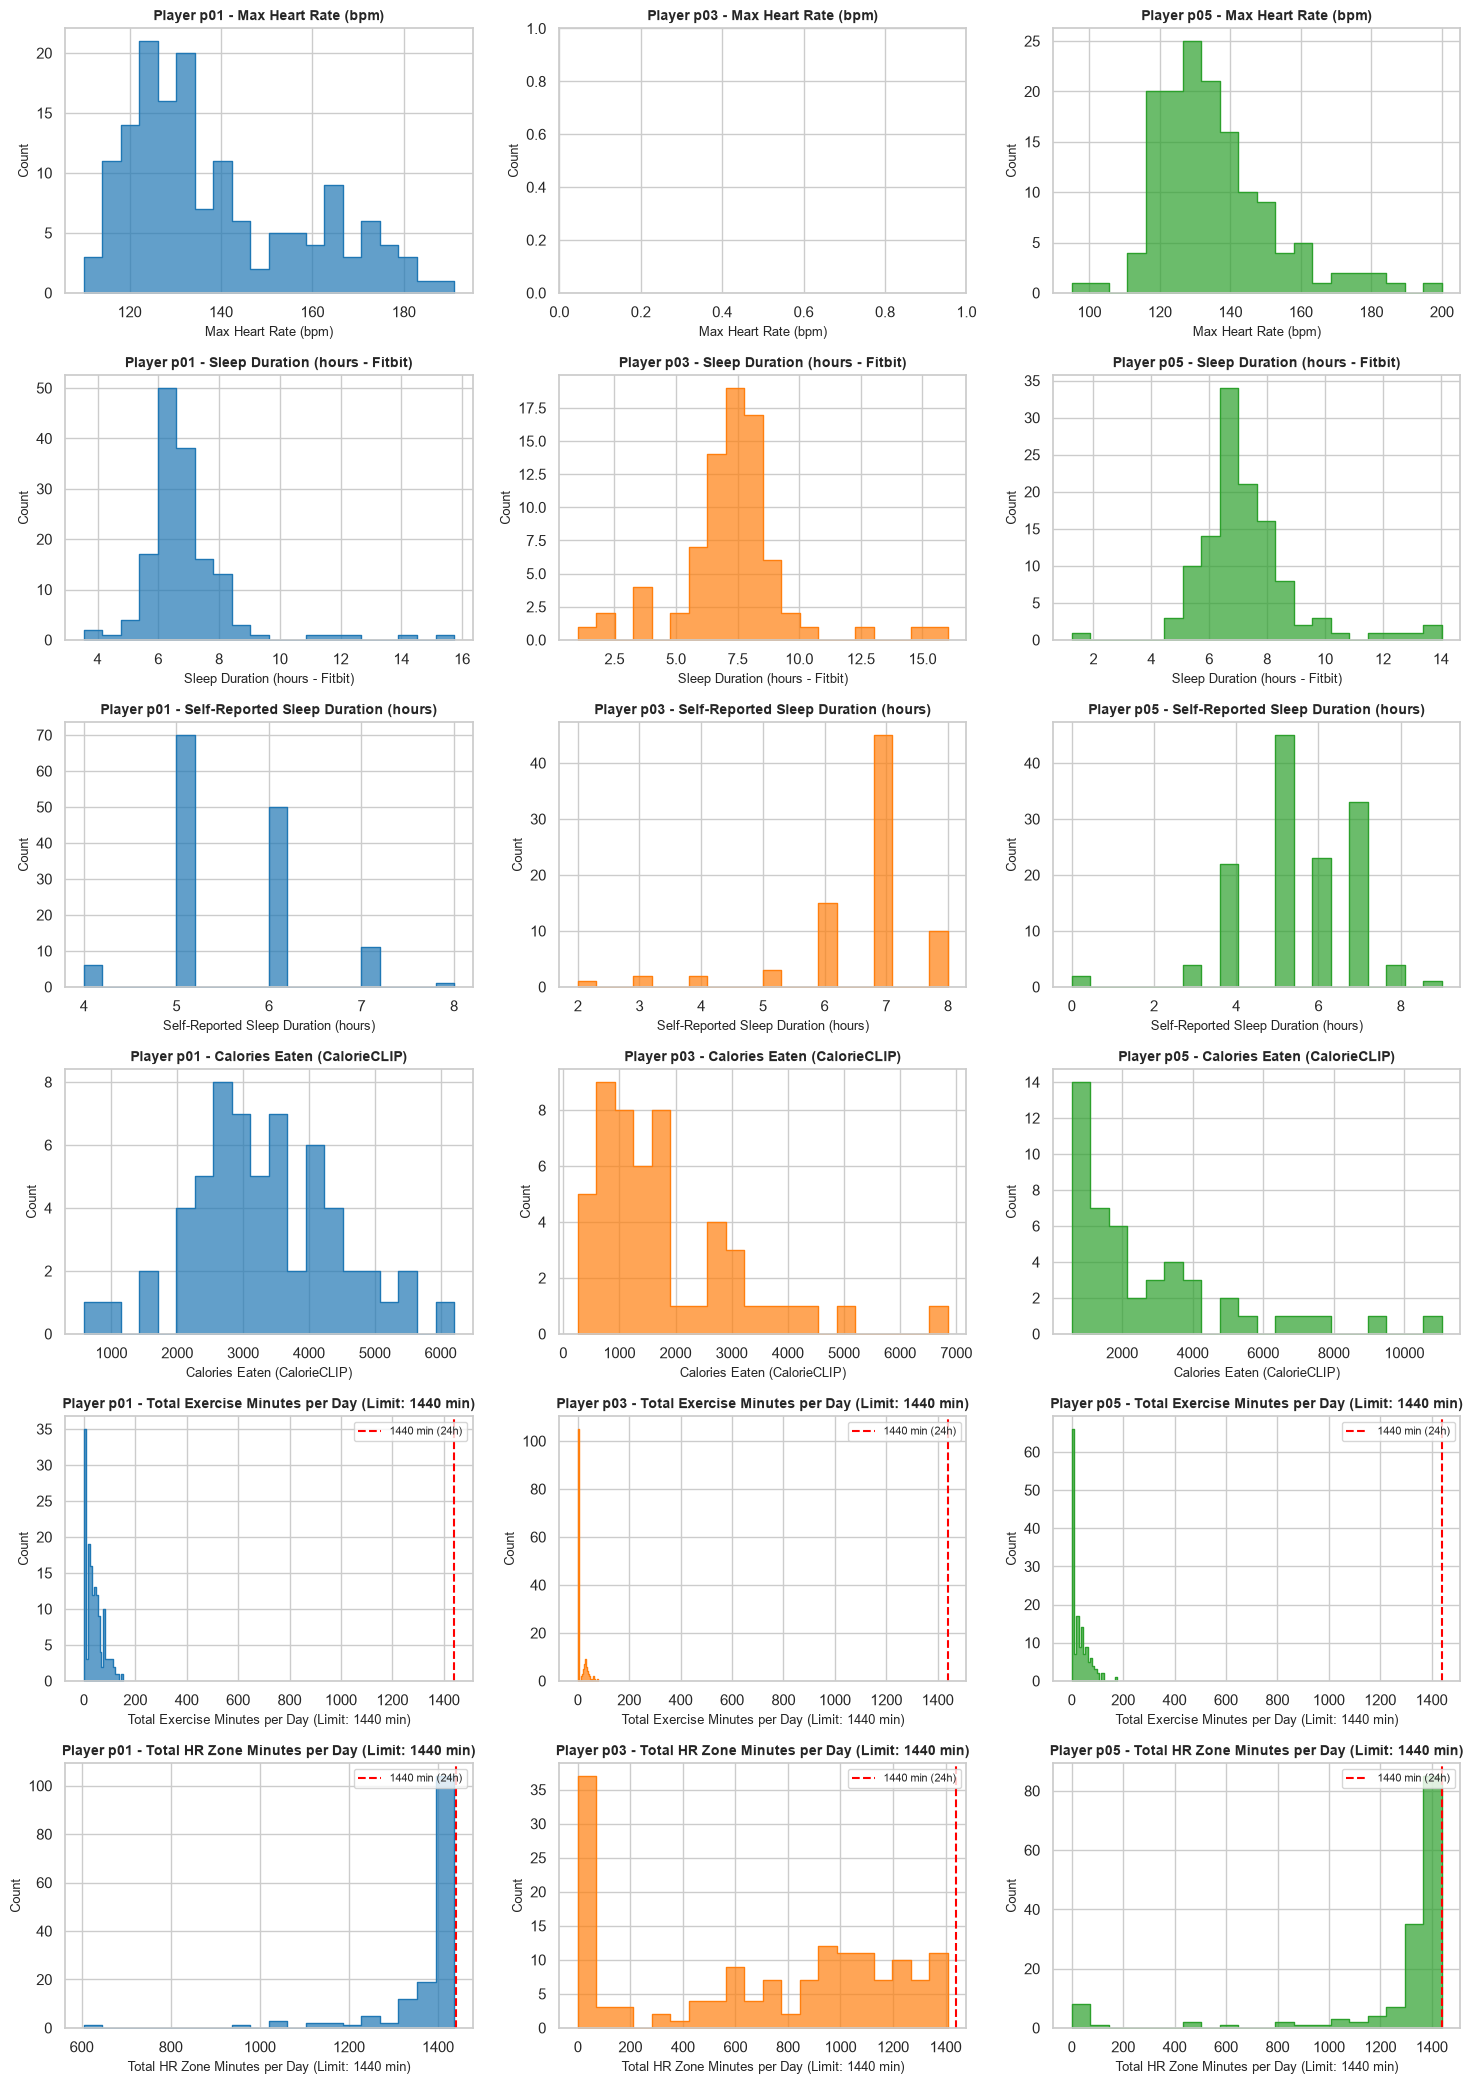

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Compute total exercise minutes and total HR zone minutes per day
ex_cols = [c for c in master_df.columns if 'exercise_time_in_zone' in c and c.endswith('_min')]
master_df['total_exercise_min'] = master_df[ex_cols].fillna(0).sum(axis=1)

hr_cols = [c for c in master_df.columns if c.startswith('Time_HR_') and c.endswith('_min')]
master_df['total_hr_zone_min'] = master_df[hr_cols].fillna(0).sum(axis=1)

metrics = [
    ('max_heart_rate', 'Max Heart Rate (bpm)'),
    ('sleep_duration', 'Sleep Duration (hours - Fitbit)'),
    ('self_sleep_duration_h', 'Self-Reported Sleep Duration (hours)'),
    ('total_calories_eaten', 'Calories Eaten (CalorieCLIP)'),
    ('total_exercise_min', 'Total Exercise Minutes per Day (Limit: 1440 min)'),
    ('total_hr_zone_min', 'Total HR Zone Minutes per Day (Limit: 1440 min)')
]

players = sorted(master_df['player'].unique())
# Define a consistent color palette for each player
palette = sns.color_palette("tab10", len(players))
player_colors = {player: palette[i] for i, player in enumerate(players)}

fig, axes = plt.subplots(len(metrics), len(players), figsize=(15, 3.5 * len(metrics)))

for row_idx, (col, title) in enumerate(metrics):
    for col_idx, player in enumerate(players):
        ax = axes[row_idx, col_idx]
        player_data = master_df[master_df['player'] == player][col].dropna()
        
        sns.histplot(
            data=player_data,
            ax=ax,
            color=player_colors[player],
            bins=20,
            alpha=0.7,
            element='step'
        )
        ax.set_title(f'Player {player} - {title}', fontsize=10, fontweight='bold')
        ax.set_xlabel(title, fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        
        # Add a reference line at 1440 minutes for totals
        if col in ['total_exercise_min', 'total_hr_zone_min']:
            ax.axvline(1440, color='red', linestyle='--', linewidth=1.5, label='1440 min (24h)')
            ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

- max heart rate: the 200 bpm value is not from the 25-years-old player but from the 35-years-old. It is not very usual, but it is not absurd, so I will keep this value. The issue is more that the player 2 doesn't have any data for this criterion. So I will leave this indicator out : the heart rate data is already partly carried by the Time_HR_[Zone]_min indicator.
- sleep duration : the 3 distributions are gaussian (feels natural), with means that are ordered by age of the player (the older is the player, the less he sleeps), which also feels natural.
- The self reported sleep is quite consistent with the value measured by the Fitbit. To detect abnormal values, I will plot the distribution of the difference between the value we measured and the one that has been reported.
- Players p03 and p05's eaten calories distributions are not gaussian. But it should be quite normally distributed around a mean value, which should be near its reference daily intake. I think they have missed meal photos. I will plot the calories eaten over time to see if we can detect some patterns to justify the weird distribution.
- total exercise minutes per day : the main part is null - it can happen. But at least, all the values are clearly under 1440 mins.
- Total HR zones min : all the values are under 1440 min : good. But for player p03, there are a lot of values that are largely under 1440 min. Maybe he wore the Fitbit less than the others.

### Total Calories Eaten Over Time per Player
Plotting the total number of calories eaten each day as a function of time for each player:

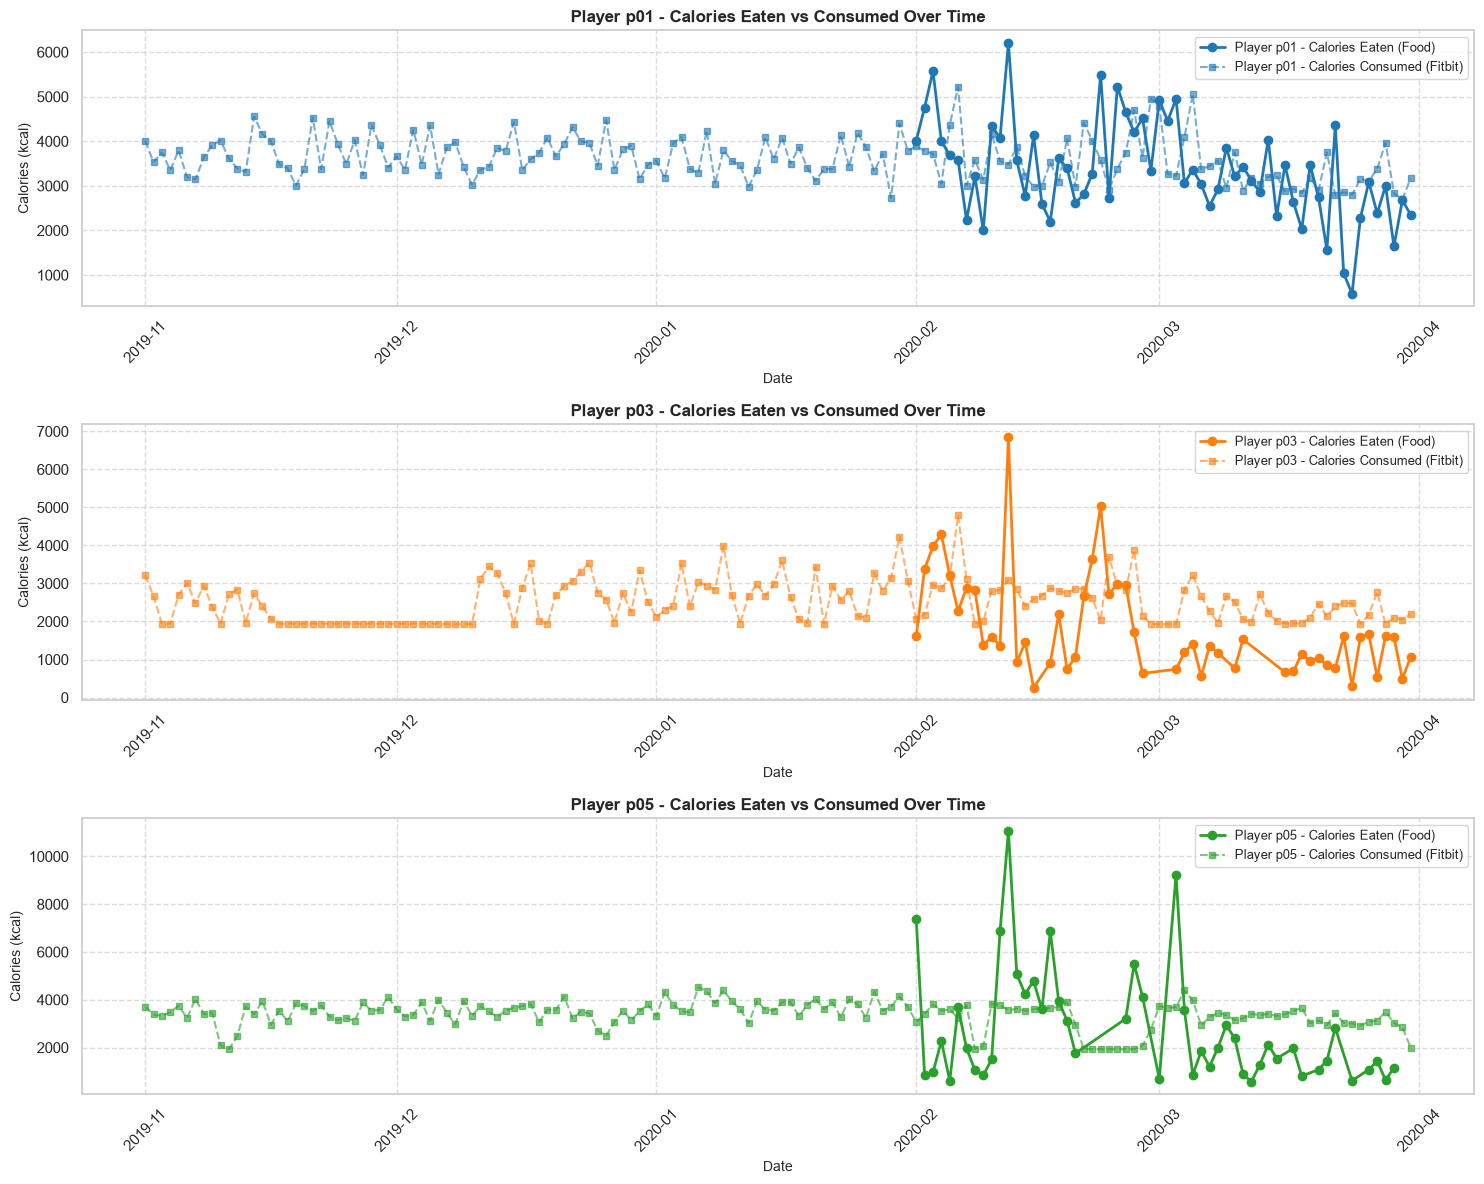

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

players = sorted(master_df["player"].unique())
palette = sns.color_palette("tab10", len(players))
player_colors = {player: palette[i] for i, player in enumerate(players)}

fig, axes = plt.subplots(len(players), 1, figsize=(15, 4 * len(players)), sharex=False, sharey=False)

if len(players) == 1:
    axes = [axes]

for idx, player in enumerate(players):
    ax = axes[idx]
    df_player = master_df[master_df["player"] == player].copy()
    df_player["date"] = pd.to_datetime(df_player["date"])
    df_player = df_player.sort_values("date")
    
    # Plot calories eaten
    df_eaten = df_player.dropna(subset=["total_calories_eaten"])
    ax.plot(
        df_eaten["date"], 
        df_eaten["total_calories_eaten"], 
        marker="o", 
        linestyle="-", 
        color=player_colors[player], 
        linewidth=2,
        markersize=6,
        label=f"Player {player} - Calories Eaten (Food)"
    )
    
    # Plot calories consumed (Fitbit)
    df_consumed = df_player.dropna(subset=["total calories consumed"])
    ax.plot(
        df_consumed["date"], 
        df_consumed["total calories consumed"], 
        marker="s", 
        linestyle="--", 
        color=player_colors[player], 
        alpha=0.6,
        linewidth=1.5,
        markersize=4,
        label=f"Player {player} - Calories Consumed (Fitbit)"
    )
    
    ax.set_title(f"Player {player} - Calories Eaten vs Consumed Over Time", fontsize=12, fontweight="bold")
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Calories (kcal)", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Some eaten calories values are weird. For example, values over 6000 for p03 and over 8000 for p05. Moreover, there is a peak of eaten calories for all the players on the 2020-02-12, with no peak in the calories consumed. This suggests there is noise in the data. Maybe some meal photos have shifted from other days.

I will change the value of this day by the mean of the 7 precedent days, and I will do the same for all values over 8000 kcal for p05 (actually there is only one).

In [59]:
# Peak total calories eaten per player
peak_per_player = master_df.loc[master_df.groupby('player')['total_calories_eaten'].idxmax()]
print(peak_per_player[['player', 'date', 'total_calories_eaten']])


    player        date  total_calories_eaten
103    p01  2020-02-12           6204.090210
255    p03  2020-02-12           6852.074738
407    p05  2020-02-12          11064.150269


### Investigating 0 values

In [60]:
print("=== Number of 0 values for total_number of steps per player ===")
if 'total_steps' in master_df.columns:
    print((master_df['total_steps'] == 0).groupby(master_df['player']).sum())
else:
    print("total_steps column not found in master_df")

print("\n=== Number of 0 values for sleep_duration per player ===")
if 'sleep_duration' in master_df.columns:
    print(master_df.groupby('player')['sleep_duration'].apply(lambda x: (x == 0).sum()))
else:
    print("sleep_duration column not found in master_df")

print("\n=== Number of 0 values for self_sleep_duration_h per player ===")
self_sleep_col = 'self_sleep_duration_h' if 'self_sleep_duration_h' in master_df.columns else ('self_sleep_duration_h_h' if 'self_sleep_duration_h_h' in master_df.columns else None)
if self_sleep_col:
    print(master_df.groupby('player')[self_sleep_col].apply(lambda x: (x == 0).sum()))
else:
    print("self_sleep_duration column not found in master_df")

=== Number of 0 values for total_number of steps per player ===
player
p01    0
p03    2
p05    0
Name: total_steps, dtype: int64

=== Number of 0 values for sleep_duration per player ===
player
p01    0
p03    0
p05    0
Name: sleep_duration, dtype: int64

=== Number of 0 values for self_sleep_duration_h per player ===
player
p01    0
p03    0
p05    2
Name: self_sleep_duration_h, dtype: int64


We will consider the 0 values in the steps as real ones.

But the 2 values == 0 in p05's sleep_duration data are from completely null lines, like : `2019-12-20T06:58:36.783Z,0,0,0,0,0,0,[],0
`. This is noise, because if the readiness was really 0, he would have had at least some fatigue, muscle soreness or stress. I will delete those in the next section.

### Consistency of sleep duration
Plotting the difference between Fitbit sleep duration and self-reported sleep duration (`sleep_duration - self_sleep_duration_h`) over time for each player:

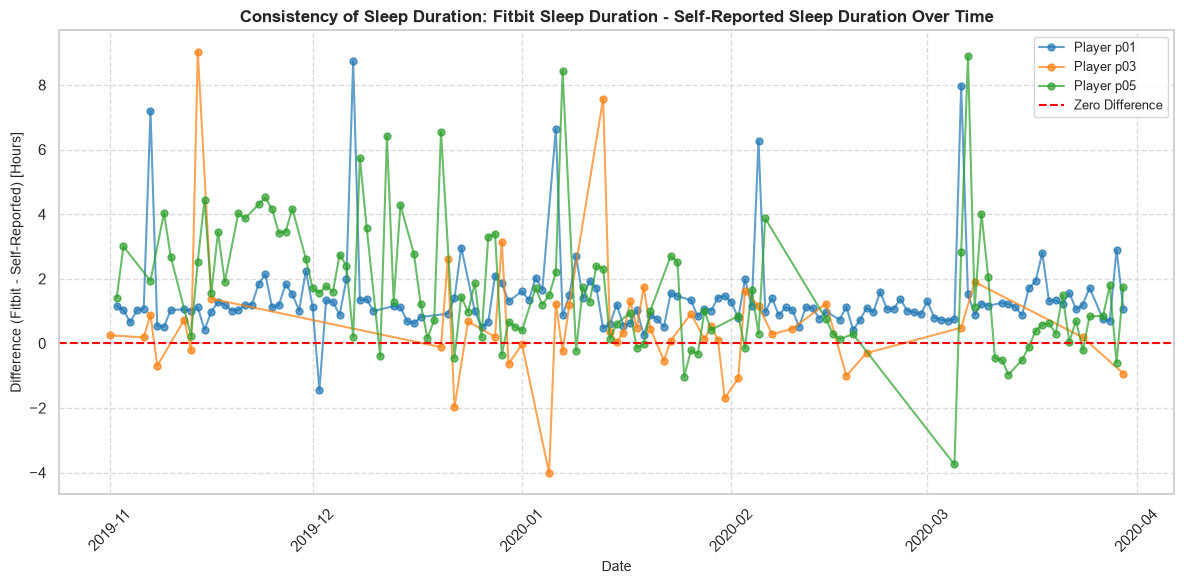

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

master_df['sleep_duration_diff'] = master_df['sleep_duration'] - master_df['self_sleep_duration_h']

players = sorted(master_df['player'].unique())
palette = sns.color_palette("tab10", len(players))
player_colors = {player: palette[i] for i, player in enumerate(players)}

fig, ax = plt.subplots(figsize=(12, 6))
for player in players:
    df_p = master_df[master_df['player'] == player].dropna(subset=['date', 'sleep_duration_diff']).copy()
    df_p['date'] = pd.to_datetime(df_p['date'])
    df_p = df_p.sort_values('date')
    ax.plot(
        df_p['date'], 
        df_p['sleep_duration_diff'], 
        marker='o', 
        linestyle='-', 
        color=player_colors[player], 
        linewidth=1.5,
        markersize=5,
        alpha=0.7,
        label=f'Player {player}'
    )

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Difference')
ax.set_title('Consistency of Sleep Duration: Fitbit Sleep Duration - Self-Reported Sleep Duration Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Difference (Fitbit - Self-Reported) [Hours]', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Remark : there is a big discrepancy between the sleep duration measured by the fitbit and the one self-reported.

### Updated resting_heart_rate, wellness calculation, and eaten calories outlier correction
Re-fetching resting heart rate (excluding error entries with null date and 0 value), wellness data (suppressing the 2 null/zero lines in p05/pmsys/wellness.csv), and correcting outlier values for total calories eaten.

In [62]:
from pathlib import Path
import pandas as pd

root_path = Path("data").resolve()
players = [p.name for p in root_path.iterdir() if p.is_dir() and (p / "pmsys" / "wellness.csv").exists()]

rhr_dfs = []
wel_dfs = []

for player in players:
    p = root_path / player
    
    # 1. Re-fetch resting_heart_rate (exclude error entries where inner date is null)
    if (p / "fitbit" / "resting_heart_rate.json").exists():
        df_rhr = pd.read_json(p / "fitbit" / "resting_heart_rate.json")
        df_rhr['date'] = pd.to_datetime(df_rhr['dateTime']).dt.strftime('%Y-%m-%d')
        def get_valid_rhr(x):
            if isinstance(x, dict) and x.get('date') is not None and pd.notna(x.get('date')):
                return x.get('value')
            return None
        df_rhr['resting_heart_rate'] = df_rhr['value'].apply(get_valid_rhr)
        df_rhr_agg = df_rhr[['date', 'resting_heart_rate']].groupby('date').min().reset_index()
        df_rhr_agg['player'] = player
        rhr_dfs.append(df_rhr_agg)
        
    # 2. Re-fetch wellness (suppress null/zero lines where all numeric wellness metrics are 0)
    if (p / "pmsys" / "wellness.csv").exists():
        df_wel = pd.read_csv(p / "pmsys" / "wellness.csv")
        num_cols = ['fatigue', 'mood', 'readiness', 'sleep_duration_h', 'sleep_quality', 'soreness', 'stress']
        df_wel = df_wel[~(df_wel[num_cols] == 0).all(axis=1)]
        df_wel['date'] = pd.to_datetime(df_wel['effective_time_frame']).dt.strftime('%Y-%m-%d')
        df_wel = df_wel.drop(columns=['effective_time_frame', 'soreness_area'], errors='ignore')
        df_wel_agg = df_wel.groupby('date').last().reset_index()
        df_wel_agg = df_wel_agg.rename(columns=lambda col: f"self_{col}" if col != 'date' else col)
        df_wel_agg['player'] = player
        wel_dfs.append(df_wel_agg)

cleaned_master_df = master_df.copy()

# Update resting_heart_rate in cleaned_master_df
if rhr_dfs:
    new_rhr_df = pd.concat(rhr_dfs, ignore_index=True)
    if 'resting_heart_rate' in cleaned_master_df.columns:
        cleaned_master_df = cleaned_master_df.drop(columns=['resting_heart_rate'])
    cleaned_master_df = pd.merge(cleaned_master_df, new_rhr_df, on=['player', 'date'], how='left')

# Update wellness columns in cleaned_master_df
if wel_dfs:
    new_wel_df = pd.concat(wel_dfs, ignore_index=True)
    wel_cols = [c for c in new_wel_df.columns if c.startswith('self_')]
    for col in wel_cols:
        if col in cleaned_master_df.columns:
            cleaned_master_df = cleaned_master_df.drop(columns=[col])
    cleaned_master_df = pd.merge(cleaned_master_df, new_wel_df, on=['player', 'date'], how='left')

cleaned_master_df['date'] = pd.to_datetime(cleaned_master_df['date'])
cleaned_master_df = cleaned_master_df.sort_values(['player', 'date'])

changed_counts = {player: 0 for player in cleaned_master_df['player'].unique()}

for player in cleaned_master_df['player'].unique():
    player_df = cleaned_master_df[cleaned_master_df['player'] == player].copy()
    for idx, row in player_df.iterrows():
        dt = row['date']
        dt_str = dt.strftime('%Y-%m-%d')
        val = row['total_calories_eaten']
        
        is_feb12 = (dt_str == '2020-02-12') and pd.notna(val)
        is_p05_over_8k = (player == 'p05') and pd.notna(val) and (val > 8000)
        
        if is_feb12 or is_p05_over_8k:
            window_start = dt - pd.Timedelta(days=7)
            precedent_mask = (cleaned_master_df['player'] == player) & (cleaned_master_df['date'] >= window_start) & (cleaned_master_df['date'] < dt) & (cleaned_master_df['total_calories_eaten'].notna())
            precedent_vals = cleaned_master_df.loc[precedent_mask, 'total_calories_eaten']
            
            if len(precedent_vals) > 0:
                mean_val = precedent_vals.mean()
            else:
                mean_val = val
                    
            cleaned_master_df.loc[idx, 'total_calories_eaten'] = mean_val
            changed_counts[player] += 1

cleaned_df = cleaned_master_df

print("Original master_df shape:", master_df.shape)
print("cleaned_master_df shape:", cleaned_master_df.shape)
print("Updated resting_heart_rate summary:")
print(cleaned_master_df['resting_heart_rate'].describe())
print("Updated self_fatigue summary:")
print(cleaned_master_df['self_sleep_duration_h'].describe())
print("\n--- Test: Number of values changed in each player's data ---")
for player, c in changed_counts.items():
    print(f"Player {player}: {c} values changed")

Original master_df shape: (456, 40)
cleaned_master_df shape: (456, 40)
Updated resting_heart_rate summary:
count    339.000000
mean      56.566214
std        5.357886
min       49.031868
25%       52.405239
50%       54.819957
75%       59.888635
max       70.602274
Name: resting_heart_rate, dtype: float64
Updated self_fatigue summary:
count    350.000000
mean       5.777143
std        1.136295
min        2.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: self_sleep_duration_h, dtype: float64

--- Test: Number of values changed in each player's data ---
Player p01: 1 values changed
Player p03: 1 values changed
Player p05: 2 values changed


Re-checking the distribution of each column :

In [63]:
players = sorted(cleaned_master_df['player'].unique())
for player in players:
    print(f"\n--- Summary for Player {player} ---")
    df_player = cleaned_master_df[cleaned_master_df['player'] == player].drop(columns=['player', 'date'], errors='ignore')
    display(df_player.describe().style.set_sticky(axis="index"))


--- Summary for Player p01 ---


,total calories consumed,exercise_time_in_zone_sedentary_min,exercise_time_in_zone_lightly_min,exercise_time_in_zone_fairly_min,exercise_time_in_zone_very_min,max_heart_rate,sleep_score,sleep_duration,total_steps,Time_HR_BELOW_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_3_min,Time_HR_IN_DEFAULT_ZONE_2_min,weight,glasses_of_fluid,Breakfast,Lunch,Dinner,Evening,sRPE_perception_x_min,total_calories_eaten,total_exercise_min,total_hr_zone_min,sleep_duration_diff,resting_heart_rate,self_fatigue,self_mood,self_readiness,self_sleep_duration_h,self_sleep_quality,self_soreness,self_stress
count,152.000000,117.000000,117.000000,117.000000,117.000000,152.000000,150.000000,150.000000,152.000000,152.000000,152.000000,152.000000,152.000000,75.000000,100.000000,100.000000,100.000000,100.000000,100.000000,31.000000,60.000000,152.000000,152.000000,137.000000,152.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,3607.612829,0.957265,4.333333,9.076923,35.871795,138.901316,71.633333,6.864000,12622.881579,1263.927632,99.447368,3.473684,5.526316,100.340000,7.960000,0.930000,0.500000,0.910000,0.350000,306.774194,3288.806686,38.671053,1372.375000,1.392822,52.276794,2.565217,2.963768,6.224638,5.500000,2.724638,2.543478,2.876812
std,507.267269,1.904591,5.304520,6.541847,26.128838,18.969044,5.634763,1.459037,4080.875255,107.841010,48.661255,7.947633,9.592317,0.663529,1.286448,0.256432,0.502519,0.287623,0.479372,136.244562,1043.878979,34.230380,104.404005,1.293120,1.307238,0.539756,0.281015,1.414307,0.737425,0.479783,0.528316,0.329851
min,2696.810000,0.000000,0.000000,0.000000,0.000000,110.000000,53.000000,3.550000,4749.000000,574.000000,22.000000,0.000000,0.000000,99.000000,5.000000,0.000000,0.000000,0.000000,0.000000,150.000000,582.628540,0.000000,605.000000,-1.450000,49.031868,1.000000,1.000000,2.000000,4.000000,1.000000,1.000000,2.000000
25%,3230.167500,0.000000,1.000000,5.000000,15.000000,124.750000,68.000000,6.116667,9850.000000,1238.250000,66.000000,0.000000,0.000000,100.000000,7.000000,1.000000,0.000000,1.000000,0.000000,205.000000,2632.535011,15.750000,1381.250000,0.883333,51.285702,2.000000,3.000000,5.000000,5.000000,2.000000,2.000000,3.000000
50%,3529.915000,0.000000,3.000000,8.000000,30.000000,133.000000,72.000000,6.608333,12229.000000,1297.000000,92.000000,0.000000,2.000000,100.000000,8.000000,1.000000,0.500000,1.000000,0.000000,280.000000,3243.810844,31.000000,1409.000000,1.116667,52.222801,3.000000,3.000000,7.000000,5.000000,3.000000,3.000000,3.000000
75%,3942.717500,1.000000,5.000000,12.000000,52.000000,153.250000,75.000000,7.212500,15462.250000,1332.500000,122.000000,1.000000,6.000000,101.000000,9.000000,1.000000,1.000000,1.000000,1.000000,380.000000,4018.409138,56.000000,1417.000000,1.400000,53.088059,3.000000,3.000000,7.000000,6.000000,3.000000,3.000000,3.000000
max,5225.820000,11.000000,29.000000,29.000000,129.000000,191.000000,88.000000,15.733333,24846.000000,1384.000000,328.000000,38.000000,56.000000,102.000000,13.000000,1.000000,1.000000,1.000000,1.000000,660.000000,5575.103912,152.000000,1436.000000,8.733333,55.931519,4.000000,4.000000,8.000000,8.000000,4.000000,3.000000,3.000000



--- Summary for Player p03 ---


,total calories consumed,exercise_time_in_zone_sedentary_min,exercise_time_in_zone_lightly_min,exercise_time_in_zone_fairly_min,exercise_time_in_zone_very_min,max_heart_rate,sleep_score,sleep_duration,total_steps,Time_HR_BELOW_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_3_min,Time_HR_IN_DEFAULT_ZONE_2_min,weight,glasses_of_fluid,Breakfast,Lunch,Dinner,Evening,sRPE_perception_x_min,total_calories_eaten,total_exercise_min,total_hr_zone_min,sleep_duration_diff,resting_heart_rate,self_fatigue,self_mood,self_readiness,self_sleep_duration_h,self_sleep_quality,self_soreness,self_stress
count,152.000000,47.000000,47.000000,47.000000,47.000000,0.000000,73.000000,78.000000,122.000000,117.000000,117.000000,117.000000,117.000000,89.000000,113.000000,113.000000,113.000000,113.000000,113.000000,2.000000,51.000000,152.000000,152.000000,47.000000,101.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2512.671513,0.978723,3.106383,4.042553,25.063830,nan,75.589041,7.302350,5358.475410,863.119658,44.222222,0.376068,1.358974,82.685393,6.230088,0.415929,0.752212,0.575221,0.796460,180.000000,1690.744721,10.263158,699.750000,0.625532,56.442242,2.935897,2.961538,4.961538,6.615385,2.987179,2.961538,2.948718
std,568.505851,1.983512,4.755930,3.641294,11.799787,nan,6.584569,2.227988,3956.541841,335.776279,46.657614,2.818432,4.940092,0.762703,1.295658,0.495077,0.433651,0.496511,0.404424,42.426407,1101.301537,17.201855,491.202582,2.019539,2.315562,0.294528,0.299016,0.299016,1.142233,0.254497,0.193552,0.274332
min,1929.600000,0.000000,0.000000,0.000000,0.000000,nan,56.000000,1.016667,0.000000,7.000000,0.000000,0.000000,0.000000,82.000000,3.000000,0.000000,0.000000,0.000000,0.000000,150.000000,259.714142,0.000000,0.000000,-4.016667,50.990494,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000
25%,1944.947500,0.000000,0.000000,1.000000,19.000000,nan,71.000000,6.470833,1266.000000,617.000000,6.000000,0.000000,0.000000,82.000000,5.000000,0.000000,1.000000,0.000000,1.000000,165.000000,877.450050,0.000000,105.500000,-0.166667,55.023738,3.000000,3.000000,5.000000,6.000000,3.000000,3.000000,3.000000
50%,2473.545000,0.000000,1.000000,3.000000,24.000000,nan,76.000000,7.308333,5832.000000,926.000000,37.000000,0.000000,0.000000,83.000000,6.000000,0.000000,1.000000,1.000000,1.000000,180.000000,1414.551697,0.000000,835.000000,0.333333,56.309516,3.000000,3.000000,5.000000,7.000000,3.000000,3.000000,3.000000
75%,2865.420000,1.000000,3.000000,6.500000,29.000000,nan,81.000000,8.179167,8340.500000,1135.000000,63.000000,0.000000,1.000000,83.000000,7.000000,1.000000,1.000000,1.000000,1.000000,195.000000,2244.187986,22.250000,1108.000000,1.175000,57.569409,3.000000,3.000000,5.000000,7.000000,3.000000,3.000000,3.000000
max,4793.300000,11.000000,17.000000,14.000000,60.000000,nan,87.000000,16.033333,16964.000000,1333.000000,266.000000,24.000000,47.000000,84.000000,10.000000,1.000000,1.000000,1.000000,1.000000,210.000000,5028.218811,79.000000,1409.000000,9.033333,64.309417,4.000000,4.000000,6.000000,8.000000,4.000000,3.000000,4.000000



--- Summary for Player p05 ---


,total calories consumed,exercise_time_in_zone_sedentary_min,exercise_time_in_zone_lightly_min,exercise_time_in_zone_fairly_min,exercise_time_in_zone_very_min,max_heart_rate,sleep_score,sleep_duration,total_steps,Time_HR_BELOW_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_1_min,Time_HR_IN_DEFAULT_ZONE_3_min,Time_HR_IN_DEFAULT_ZONE_2_min,weight,glasses_of_fluid,Breakfast,Lunch,Dinner,Evening,sRPE_perception_x_min,total_calories_eaten,total_exercise_min,total_hr_zone_min,sleep_duration_diff,resting_heart_rate,self_fatigue,self_mood,self_readiness,self_sleep_duration_h,self_sleep_quality,self_soreness,self_stress
count,152.000000,86.000000,86.000000,86.000000,86.000000,145.000000,117.000000,118.000000,144.000000,145.000000,145.000000,145.000000,145.000000,97.000000,117.000000,117.000000,117.000000,117.000000,117.000000,8.000000,47.000000,152.000000,152.000000,105.000000,86.000000,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000
mean,3385.379605,1.430233,6.209302,14.790698,26.465116,134.944828,79.931624,7.191525,11389.736111,1143.641379,169.675862,0.241379,2.324138,100.856701,9.598291,0.666667,0.880342,0.965812,0.666667,207.500000,2443.274976,27.664474,1255.282895,1.687619,64.293111,2.716418,2.723881,2.843284,5.574627,2.708955,3.022388,2.582090
std,569.288183,2.956710,6.822310,10.270593,18.479685,16.374429,5.812778,1.719447,4117.520591,212.004641,99.314517,1.174237,5.270308,1.002383,3.792142,0.473432,0.325957,0.182493,0.473432,96.621500,1788.119413,32.743018,350.795716,1.973312,3.388357,0.595875,0.798418,2.482584,1.240767,0.502993,0.228312,0.843360
min,1929.600000,0.000000,0.000000,0.000000,0.000000,95.000000,59.000000,1.250000,13.000000,24.000000,0.000000,0.000000,0.000000,99.000000,3.000000,0.000000,0.000000,0.000000,0.000000,90.000000,571.857422,0.000000,0.000000,-3.750000,57.459719,1.000000,1.000000,0.000000,3.000000,1.000000,2.000000,1.000000
25%,3144.130000,0.000000,2.000000,7.000000,10.250000,124.000000,77.000000,6.416667,9013.250000,1116.000000,108.000000,0.000000,0.000000,100.000000,7.000000,0.000000,1.000000,1.000000,0.000000,142.500000,1067.815353,0.000000,1322.250000,0.300000,61.902159,3.000000,2.000000,0.000000,5.000000,2.000000,3.000000,2.000000
50%,3504.980000,0.000000,4.000000,13.000000,23.500000,132.000000,80.000000,6.866667,11857.500000,1200.000000,152.000000,0.000000,0.000000,101.000000,9.000000,1.000000,1.000000,1.000000,1.000000,200.000000,1966.468689,19.000000,1375.000000,1.416667,63.488887,3.000000,3.000000,5.000000,5.000000,3.000000,3.000000,3.000000
75%,3734.495000,1.000000,8.750000,19.750000,39.000000,143.000000,84.000000,7.754167,13802.750000,1265.000000,216.000000,0.000000,2.000000,101.000000,11.000000,1.000000,1.000000,1.000000,1.000000,255.000000,3472.322226,46.000000,1415.250000,2.700000,67.696842,3.000000,3.000000,5.000000,7.000000,3.000000,3.000000,3.000000
max,4528.580000,16.000000,43.000000,50.000000,89.000000,200.000000,92.000000,14.033333,23971.000000,1369.000000,689.000000,9.000000,34.000000,103.000000,20.000000,1.000000,1.000000,1.000000,1.000000,380.000000,7393.938049,177.000000,1439.000000,8.900000,70.602274,4.000000,4.000000,8.000000,9.000000,4.000000,4.000000,4.000000


Now data seems consistent.

# Missing values management